We are going to perform a sentence-level sentiment analysis using lexicons AFINN and VADER.

For this we have defined a series of auxiliar functions that do the following:

1. Load a plain-text corpus from a file in text format.
2. Split the corpus into sentences.
3. Compute two lexicon-based sentiment scores per sentence:
   - AFINN additive score: this turns out to be an unbounded integer sum, hence we also provide a simple normalization.
   - VADER compound score: a bounded score, with $\text{score}\,\in\,[-1, 1]$.
4. Plot sentiment evolution over the corpus. This allow us to detect relevant moments in the discourse.

The script requires that we have `spacy`, `afinn`, `nltk`, and `matplotlib`. Also, do not forget that `spacy` needs that we load the language model, which in this case is `en_core_web_sm`.

The corpus was generated by ChatGPT under the requirement that it generates a discourse to be studied via sentiment analysis.

In [ ]:
corpus = """
My friends,

Tonight we gather at a moment of uncertainty. Many of you feel concern about the future, and I understand that concern. We have faced challenges before, and we will face them again.

Our economy has struggled. Families have worried about their jobs. Small businesses have wondered whether they could survive another year. These difficulties are real, and they have caused frustration and fear.

But let us not forget who we are. We are a nation built on resilience. We are a people who do not retreat when circumstances become hard. We adapt, we learn, and we rise.

There have been mistakes. There have been delays. Some decisions have not produced the results we hoped for. That disappointment is natural, and it is justified.

Yet even in these moments, we see signs of strength. Communities are supporting one another. Teachers are inspiring their students. Scientists are working tirelessly to build better solutions.

Hope is not naive optimism. Hope is the conviction that effort matters. Hope is the belief that tomorrow can be better because we choose to act today.

We will invest in innovation. We will protect the most vulnerable among us. We will create opportunities for those who have been left behind.

There will be obstacles. There will be criticism. There will be days when progress feels painfully slow.

But we will not give in to despair. We will not allow division to weaken our common purpose. We will move forward together.

The path ahead will require courage. It will demand patience. It will test our unity.

And still, I am confident. I am confident in your strength. I am confident in our shared values. I am confident that the future we build will be brighter than the past we leave behind.

Let us begin.
"""


In [ ]:
corpus = """
Thank you very kindly, my friends. As I listened to Ralph Abernathy in his eloquent and generous introduction and then thought about myself, I wondered who he was talking about. It's always good to have your closest friend and associate say something good about you. And Ralph is the best friend that I have in the world.

I'm delighted to see each of you here tonight in spite of a storm warning. You reveal that you are determined to go on anyhow. Something is happening in Memphis, something is happening in our world.

As you know, if I were standing at the beginning of time, with the possibility of general and panoramic view of the whole human history up to now, and the Almighty said to me, "Martin Luther King, which age would you like to live in?" — I would take my mental flight by Egypt through, or rather across the Red Sea, through the wilderness on toward the promised land. And in spite of its magnificence, I wouldn't stop there. I would move on by Greece, and take my mind to Mount Olympus. And I would see Plato, Aristotle, Socrates, Euripides and Aristophanes assembled around the Parthenon as they discussed the great and eternal issues of reality.

But I wouldn't stop there. I would go on, even to the great heyday of the Roman Empire. And I would see developments around there, through various emperors and leaders. But I wouldn't stop there. I would even come up to the day of the Renaissance, and get a quick picture of all that the Renaissance did for the cultural and esthetic life of man. But I wouldn't stop there. I would even go by the way that the man for whom I'm named had his habitat. And I would watch Martin Luther as he tacked his ninety-five theses on the door at the church in Wittenberg.

But I wouldn't stop there. I would come on up even to 1863, and watch a vacillating president by the name of Abraham Lincoln finally come to the conclusion that he had to sign the Emancipation Proclamation. But I wouldn't stop there. I would even come up to the early thirties, and see a man grappling with the problems of the bankruptcy of his nation. And come with an eloquent cry that we have nothing to fear but fear itself.

But I wouldn't stop there. Strangely enough, I would turn to the Almighty, and say, "If you allow me to live just a few years in the second half of the twentieth century, I will be happy." Now that's a strange statement to make, because the world is all messed up. The nation is sick. Trouble is in the land. Confusion all around. That's a strange statement. But I know, somehow, that only when it is dark enough, can you see the stars. And I see God working in this period of the twentieth century in a away that men, in some strange way, are responding — something is happening in our world. The masses of people are rising up. And wherever they are assembled today, whether they are in Johannesburg, South Africa; Nairobi, Kenya; Accra, Ghana; New York City; Atlanta, Georgia; Jackson, Mississippi; or Memphis, Tennessee — the cry is always the same — "We want to be free."

And another reason that I'm happy to live in this period is that we have been forced to a point where we're going to have to grapple with the problems that men have been trying to grapple with through history, but the demand didn't force them to do it. Survival demands that we grapple with them. Men, for years now, have been talking about war and peace. But now, no longer can they just talk about it. It is no longer a choice between violence and nonviolence in this world; it's nonviolence or nonexistence.

That is where we are today. And also in the human rights revolution, if something isn't done, and in a hurry, to bring the colored peoples of the world out of their long years of poverty, their long years of hurt and neglect, the whole world is doomed. Now, I'm just happy that God has allowed me to live in this period, to see what is unfolding. And I'm happy that He's allowed me to be in Memphis.

I can remember, I can remember when Negroes were just going around as Ralph has said, so often, scratching where they didn't itch, and laughing when they were not tickled. But that day is all over. We mean business now, and we are determined to gain our rightful place in God's world.

And that's all this whole thing is about. We aren't engaged in any negative protest and in any negative arguments with anybody. We are saying that we are determined to be men. We are determined to be people. We are saying that we are God's children. And that we don't have to live like we are forced to live.

Now, what does all of this mean in this great period of history? It means that we've got to stay together. We've got to stay together and maintain unity. You know, whenever Pharaoh wanted to prolong the period of slavery in Egypt, he had a favorite, favorite formula for doing it. What was that? He kept the slaves fighting among themselves. But whenever the slaves get together, something happens in Pharaoh's court, and he cannot hold the slaves in slavery. When the slaves get together, that's the beginning of getting out of slavery. Now let us maintain unity.

Secondly, let us keep the issues where they are. The issue is injustice. The issue is the refusal of Memphis to be fair and honest in its dealings with its public servants, who happen to be sanitation workers. Now, we've got to keep attention on that. That's always the problem with a little violence. You know what happened the other day, and the press dealt only with the window-breaking. I read the articles. They very seldom got around to mentioning the fact that one thousand, three hundred sanitation workers were on strike, and that Memphis is not being fair to them, and that Mayor Loeb is in dire need of a doctor. They didn't get around to that.

Now we're going to march again, and we've got to march again, in order to put the issue where it is supposed to be. And force everybody to see that there are thirteen hundred of God's children here suffering, sometimes going hungry, going through dark and dreary nights wondering how this thing is going to come out. That's the issue. And we've got to say to the nation: we know it's coming out. For when people get caught up with that which is right and they are willing to sacrifice for it, there is no stopping point short of victory.

We aren't going to let any mace stop us. We are masters in our nonviolent movement in disarming police forces; they don't know what to do, I've seen them so often. I remember in Birmingham, Alabama, when we were in that majestic struggle there we would move out of the 16th Street Baptist Church day after day; by the hundreds we would move out. And Bull Connor would tell them to send the dogs forth and they did come; but we just went before the dogs singing, "Ain't gonna let nobody turn me round." Bull Connor next would say, "Turn the fire hoses on." And as I said to you the other night, Bull Connor didn't know history. He knew a kind of physics that somehow didn't relate to the transphysics that we knew about. And that was the fact that there was a certain kind of fire that no water could put out. And we went before the fire hoses; we had known water. If we were Baptist or some other denomination, we had been immersed. If we were Methodist, and some others, we had been sprinkled, but we knew water.

That couldn't stop us. And we just went on before the dogs and we would look at them; and we'd go on before the water hoses and we would look at it, and we'd just go on singing "Over my head I see freedom in the air." And then we would be thrown in the paddy wagons, and sometimes we were stacked in there like sardines in a can. And they would throw us in, and old Bull would say, "Take them off," and they did; and we would just go in the paddy wagon singing, "We Shall Overcome." And every now and then we'd get in the jail, and we'd see the jailers looking through the windows being moved by our prayers, and being moved by our words and our songs. And there was a power there which Bull Connor couldn't adjust to; and so we ended up transforming Bull into a steer, and we won our struggle in Birmingham.

Now we've got to go on to Memphis just like that. I call upon you to be with us Monday. Now about injunctions: We have an injunction and we're going into court tomorrow morning to fight this illegal, unconstitutional injunction. All we say to America is, "Be true to what you said on paper." If I lived in China or even Russia, or any totalitarian country, maybe I could understand the denial of certain basic First Amendment privileges, because they hadn't committed themselves to that over there. But somewhere I read of the freedom of assembly. Somewhere I read of the freedom of speech. Somewhere I read of the freedom of the press. Somewhere I read that the greatness of America is the right to protest for right. And so just as I say, we aren't going to let any injunction turn us around. We are going on.

We need all of you. And you know what's beautiful tome, is to see all of these ministers of the Gospel. It's a marvelous picture. Who is it that is supposed to articulate the longings and aspirations of the people more than the preacher? Somehow the preacher must be an Amos, and say, "Let justice roll down like waters and righteousness like a mighty stream." Somehow, the preacher must say with Jesus, "The spirit of the Lord is upon me, because he hath anointed me to deal with the problems of the poor."

And I want to commend the preachers, under the leadership of these noble men: James Lawson, one who has been in this struggle for many years; he's been to jail for struggling; but he's still going on, fighting for the rights of his people. Rev. Ralph Jackson, Billy Kiles; I could just go right on down the list, but time will not permit. But I want to thank them all. And I want you to thank them, because so often, preachers aren't concerned about anything but themselves. And I'm always happy to see a relevant ministry.

It's all right to talk about "long white robes over yonder," in all of its symbolism. But ultimately people want some suits and dresses and shoes to wear down here. It's all right to talk about "streets flowing with milk and honey," but God has commanded us to be concerned about the slums down here, and his children who can't eat three square meals a day. It's all right to talk about the new Jerusalem, but one day, God's preachers must talk about the New York, the new Atlanta, the new Philadelphia, the new Los Angeles, the new Memphis, Tennessee. This is what we have to do.

Now the other thing we'll have to do is this: Always anchor our external direct action with the power of economic withdrawal. Now, we are poor people, individually, we are poor when you compare us with white society in America. We are poor. Never stop and forget that collectively, that means all of us together, collectively we are richer than all the nations in the world, with the exception of nine. Did you ever think about that? After you leave the United States, Soviet Russia, Great Britain, West Germany, France, and I could name the others, the Negro collectively is richer than most nations of the world. We have an annual income of more than thirty billion dollars a year, which is more than all of the exports of the United States, and more than the national budget of Canada. Did you know that? That's power right there, if we know how to pool it.

We don't have to argue with anybody. We don't have to curse and go around acting bad with our words. We don't need any bricks and bottles, we don't need any Molotov cocktails, we just need to go around to these stores, and to these massive industries in our country, and say, "God sent us by here, to say to you that you're not treating his children right. And we've come by here to ask you to make the first item on your agenda fair treatment, where God's children are concerned. Now, if you are not prepared to do that, we do have an agenda that we must follow. And our agenda calls for withdrawing economic support from you."

And so, as a result of this, we are asking you tonight, to go out and tell your neighbors not to buy Coca-Cola in Memphis. Go by and tell them not to buy Sealtest milk. Tell them not to buy—what is the other bread?—Wonder Bread. And what is the other bread company, Jesse? Tell them not to buy Hart's bread. As Jesse Jackson has said, up to now, only the garbage men have been feeling pain; now we must kind of redistribute the pain. We are choosing these companies because they haven't been fair in their hiring policies; and we are choosing them because they can begin the process of saying, they are going to support the needs and the rights of these men who are on strike. And then they can move on downtown and tell Mayor Loeb to do what is right.

But not only that, we've got to strengthen black institutions. I call upon you to take your money out of the banks downtown and deposit your money in Tri-State Bank—we want a "bank-in" movement in Memphis. So go by the savings and loan association. I'm not asking you something we don't do ourselves at SCLC. Judge Hooks and others will tell you that we have an account here in the savings and loan association from the Southern Christian Leadership Conference. We're just telling you to follow what we're doing. Put your money there. You have six or seven black insurance companies in Memphis. Take out your insurance there. We want to have an "insurance-in."

Now these are some practical things we can do. We begin the process of building a greater economic base. And at the same time, we are putting pressure where it really hurts. I ask you to follow through here.

Now, let me say as I move to my conclusion that we've got to give ourselves to this struggle until the end. Nothing would be more tragic than to stop at this point, in Memphis. We've got to see it through. And when we have our march, you need to be there. Be concerned about your brother. You may not be on strike. But either we go up together, or we go down together.

Let us develop a kind of dangerous unselfishness. One day a man came to Jesus; and he wanted to raise some questions about some vital matters in life. At points, he wanted to trick Jesus, and show him that he knew a little more than Jesus knew, and through this, throw him off base. Now that question could have easily ended up in a philosophical and theological debate. But Jesus immediately pulled that question from mid-air, and placed it on a dangerous curve between Jerusalem and Jericho. And he talked about a certain man, who fell among thieves. You remember that a Levite and a priest passed by on the other side. They didn't stop to help him. And finally a man of another race came by. He got down from his beast, decided not to be compassionate by proxy. But with him, administering first aid, and helped the man in need. Jesus ended up saying, this was the good man, this was the great man, because he had the capacity to project the "I" into the "thou," and to be concerned about his brother. Now you know, we use our imagination a great deal to try to determine why the priest and the Levite didn't stop. At times we say they were busy going to church meetings—an ecclesiastical gathering—and they had to get on down to Jerusalem so they wouldn't be late for their meeting. At other times we would speculate that there was a religious law that "One who was engaged in religious ceremonials was not to touch a human body twenty-four hours before the ceremony." And every now and then we begin to wonder whether maybe they were not going down to Jerusalem, or down to Jericho, rather to organize a "Jericho Road Improvement Association." That's a possibility. Maybe they felt that it was better to deal with the problem from the causal root, rather than to get bogged down with an individual effort.

But I'm going to tell you what my imagination tells me. It's possible that these men were afraid. You see, the Jericho road is a dangerous road. I remember when Mrs. King and I were first in Jerusalem. We rented a car and drove from Jerusalem down to Jericho. And as soon as we got on that road, I said to my wife, "I can see why Jesus used this as a setting for his parable." It's a winding, meandering road. It's really conducive for ambushing. You start out in Jerusalem, which is about 1200 miles, or rather 1200 feet above sea level. And by the time you get down to Jericho, fifteen or twenty minutes later, you're about 2200 feet below sea level. That's a dangerous road. In the days of Jesus it came to be known as the "Bloody Pass." And you know, it's possible that the priest and the Levite looked over that man on the ground and wondered if the robbers were still around. Or it's possible that they felt that the man on the ground was merely faking. And he was acting like he had been robbed and hurt, in order to seize them over there, lure them there for quick and easy seizure. And so the first question that the Levite asked was, "If I stop to help this man, what will happen to me?" But then the Good Samaritan came by. And he reversed the question: "If I do not stop to help this man, what will happen to him?"

That's the question before you tonight. Not, "If I stop to help the sanitation workers, what will happen to all of the hours that I usually spend in my office every day and every week as a pastor?" The question is not, "If I stop to help this man in need, what will happen to me?" "If I do not stop to help the sanitation workers, what will happen to them?" That's the question.

Let us rise up tonight with a greater readiness. Let us stand with a greater determination. And let us move on in these powerful days, these days of challenge to make America what it ought to be. We have an opportunity to make America a better nation. And I want to thank God, once more, for allowing me to be here with you.

You know, several years ago, I was in New York City autographing the first book that I had written. And while sitting there autographing books, a demented black woman came up. The only question I heard from her was, "Are you Martin Luther King?"

And I was looking down writing, and I said yes. And the next minute I felt something beating on my chest. Before I knew it I had been stabbed by this demented woman. I was rushed to Harlem Hospital. It was a dark Saturday afternoon. And that blade had gone through, and the X-rays revealed that the tip of the blade was on the edge of my aorta, the main artery. And once that's punctured, you drown in your own blood—that's the end of you.

It came out in the New York Times the next morning, that if I had sneezed, I would have died. Well, about four days later, they allowed me, after the operation, after my chest had been opened, and the blade had been taken out, to move around in the wheel chair in the hospital. They allowed me to read some of the mail that came in, and from all over the states, and the world, kind letters came in. I read a few, but one of them I will never forget. I had received one from the President and the Vice-President. I've forgotten what those telegrams said. I'd received a visit and a letter from the Governor of New York, but I've forgotten what the letter said. But there was another letter that came from a little girl, a young girl who was a student at the White Plains High School. And I looked at that letter, and I'll never forget it. It said simply, "Dear Dr. King: I am a ninth-grade student at the White Plains High School." She said, "While it should not matter, I would like to mention that I am a white girl. I read in the paper of your misfortune, and of your suffering. And I read that if you had sneezed, you would have died. And I'm simply writing you to say that I'm so happy that you didn't sneeze."

And I want to say tonight, I want to say that I am happy that I didn't sneeze. Because if I had sneezed, I wouldn't have been around here in 1960, when students all over the South started sitting-in at lunch counters. And I knew that as they were sitting in, they were really standing up for the best in the American dream. And taking the whole nation back to those great wells of democracy which were dug deep by the Founding Fathers in the Declaration of Independence and the Constitution. If I had sneezed, I wouldn't have been around in 1962, when Negroes in Albany, Georgia, decided to straighten their backs up. And whenever men and women straighten their backs up, they are going somewhere, because a man can't ride your back unless it is bent. If I had sneezed, I wouldn't have been here in 1963, when the black people of Birmingham, Alabama, aroused the conscience of this nation, and brought into being the Civil Rights Bill. If I had sneezed, I wouldn't have had a chance later that year, in August, to try to tell America about a dream that I had had. If I had sneezed, I wouldn't have been down in Selma, Alabama, been in Memphis to see the community rally around those brothers and sisters who are suffering. I'm so happy that I didn't sneeze.

And they were telling me, now it doesn't matter now. It really doesn't matter what happens now. I left Atlanta this morning, and as we got started on the plane, there were six of us, the pilot said over the public address system, "We are sorry for the delay, but we have Dr. Martin Luther King on the plane. And to be sure that all of the bags were checked, and to be sure that nothing would be wrong with the plane, we had to check out everything carefully. And we've had the plane protected and guarded all night."

And then I got to Memphis. And some began to say the threats, or talk about the threats that were out. What would happen to me from some of our sick white brothers?

Well, I don't know what will happen now. We've got some difficult days ahead. But it doesn't matter with me now. Because I've been to the mountaintop. And I don't mind. Like anybody, I would like to live a long life. Longevity has its place. But I'm not concerned about that now. I just want to do God's will. And He's allowed me to go up to the mountain. And I've looked over. And I've seen the promised land. I may not get there with you. But I want you to know tonight, that we, as a people, will get to the promised land. And I'm happy, tonight. I'm not worried about anything. I'm not fearing any man. Mine eyes have seen the glory of the coming of the Lord.
"""

# Modules

Here we are just going to load general modules, but the ones which are task-specific will be loaded within the functions provided below

In [ ]:
!pip install afinn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=18e68323430d3a6df2765f458127e7a571acdc1f446d55fc47497b9bc26bcc1a
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt

try:
  import spacy
except Exception as e:
  raise RuntimeError(
      "spaCy model not available.\n"
      "Run:\n"
      "  python -m spacy download en_core_web_sm"
      ) from e

try:
  from afinn import Afinn
except Exception as e:
  raise RuntimeError(
      "AFINN not installed.\n"
      "Run:\n"
      "  pip install afinn"
      ) from e

try:
  import nltk
  from nltk.sentiment import SentimentIntensityAnalyzer
except Exception as e:
  raise RuntimeError(
      "NLTK not installed.\n"
      "Run:\n"
      "  pip install nltk"
      ) from e

try:
  nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
  nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


# Helper Functions

It is true that we may not need the functions below and everything could go as a single code snippet. We just do it to have a cleaner document.

In [ ]:
# ----------------------------
# I/O
# ----------------------------

def load_text(path: str) -> str:
    """
    Load a UTF-8 text file and return its contents.
    """
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    except FileNotFoundError as e:
        raise FileNotFoundError(f"File not found: {path}") from e
    except UnicodeDecodeError as e:
        raise UnicodeDecodeError("utf-8", b"", 0, 1, f"Could not decode {path} as UTF-8.") from e


# ----------------------------
# Sentence splitting + cleanup
# ----------------------------
def split_sentences(text: str) -> List[str]:
    """
    Split text into sentences using spaCy.
    """
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)

    sentences: List[str] = []
    for sent in doc.sents:
        s = sent.text.strip()
        if s:
            sentences.append(s)
    return sentences


# ----------------------------
# Lexicon scoring
# ----------------------------

@dataclass
class SentenceScores:
    sentence: str
    afinn_raw: float
    afinn_norm: float
    vader_compound: float


def afinn_score(sentence: str, afn) -> float:
    """
    AFINN additive score (raw).
    """
    return float(afn.score(sentence))


def afinn_normalize(raw_score: float, sentence: str) -> float:
    """
    Simple normalization: divide by number of alphabetic tokens.
    This is not 'the' standard, but it helps compare across sentence lengths.
    """
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(sentence)
    n_alpha = sum(1 for tok in doc if tok.is_alpha)
    if n_alpha == 0:
        return 0.0
    return raw_score / n_alpha


def vader_compound(sentence: str, sia) -> float:
    """
    VADER compound score in [-1, 1].
    """
    return float(sia.polarity_scores(sentence)["compound"])


def score_sentences(sentences: List[str]) -> List[SentenceScores]:
    """
    Compute AFINN and VADER scores for each sentence.
    """
    afn = Afinn()
    sia = SentimentIntensityAnalyzer()

    out: List[SentenceScores] = []
    for s in sentences:
        raw = afinn_score(s, afn)
        norm = afinn_normalize(raw, s)
        comp = vader_compound(s, sia)
        out.append(SentenceScores(sentence=s, afinn_raw=raw, afinn_norm=norm, vader_compound=comp))

    return out


# ----------------------------
# Time axis + plotting
# ----------------------------

def make_time_index(n: int, normalize: bool = True) -> List[float]:
    """
    Create a time index for n sentences.
    If normalize=True, outputs values in [0, 1].
    """
    if n <= 0:
        return []
    if not normalize:
        return list(range(1, n + 1))

    denom = max(1, n - 1)
    return [i / denom for i in range(n)]


def plot_time_series(time: List[float], values: List[float], xlabel: str, ylabel: str, title:str) -> None:
    """
    Plot a single time series (matplotlib).
    """

    if len(time) != len(values):
        raise ValueError("time and values must have the same length.")

    plt.plot(time, values)
    plt.axhline(0.0)
    plt.xlabel(xlabel, fontsize=10)
    plt.tick_params(labelsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.title(title, fontsize=12)

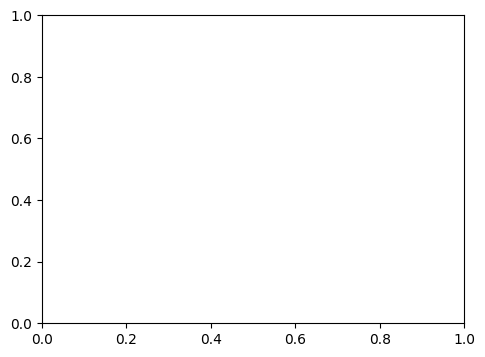

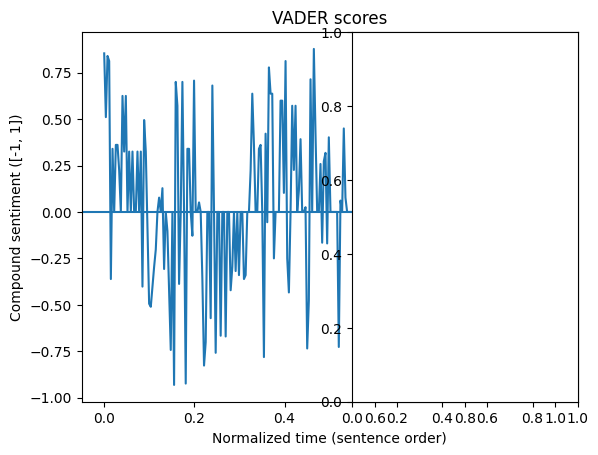

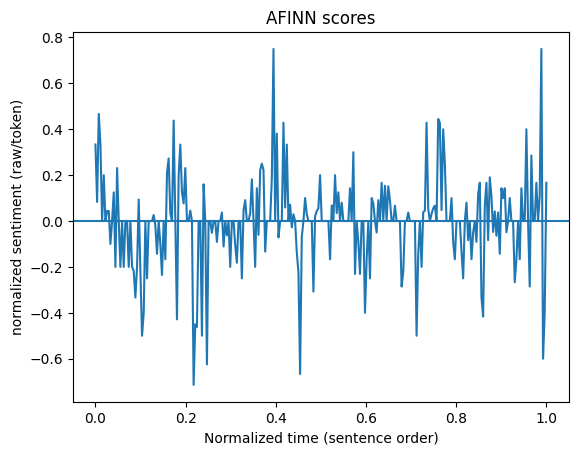


Top 5 most positive sentences (VADER):
 0.878 | After you leave the United States, Soviet Russia, Great Britain, West Germany, France, and I could name the others, the Negro collectively is richer than most nations of the world.
 0.854 | Thank you very kindly, my friends.
 0.840 | It's always good to have your closest friend and associate say something good about you.
 0.813 | And Ralph is the best friend that I have in the world.
 0.813 | Somehow the preacher must be an Amos, and say, "Let justice roll down like waters and righteousness like a mighty stream."

Top 5 most negative sentences (VADER):
-0.931 | And also in the human rights revolution, if something isn't done, and in a hurry, to bring the colored peoples of the world out of their long years of poverty, their long years of hurt and neglect, the whole world is doomed.
-0.924 | We aren't engaged in any negative protest and in any negative arguments with anybody.
-0.827 | But whenever the slaves get together, something happen

In [ ]:
def main():
    # 1) Load corpus text from file
    # path = "speech.txt"
    # text = load_text(path)
    # since we are loading the corpus directly in this colab, we do not need them
    # change this part as you need

    # 2) Split into sentences
    sentences = split_sentences(corpus)   # instead of corpus you can use "text" if you
                                          # have the corpus in a file as in the previous
                                          # chunk
    if not sentences:
        raise RuntimeError("No sentences detected. Check the input text.")

    # 3) Score each sentence with two lexicon approaches
    scored = score_sentences(sentences)

    # 4) Build time index
    t = make_time_index(len(scored), normalize=True)

    # 5) Plot sentiment evolutions
    plt.figure(figsize=(12, 4))

    # Plot VADER compound (already in [-1, 1])
    plt.subplot2grid((1, 2), (0, 0))
    vader_vals = [x.vader_compound for x in scored]
    plot_time_series(
        t, vader_vals,
        xlabel="Normalized time (sentence order)",
        ylabel="Compound sentiment ([-1, 1])",
        title="VADER scores"
    )

    # Plot AFINN normalized score (roughly comparable across sentence lengths)
    plt.subplot2grid((1, 2), (0, 1))
    afinn_vals = [x.afinn_norm for x in scored]
    plot_time_series(
        t, afinn_vals,
        xlabel="Normalized time (sentence order)",
        ylabel="normalized sentiment (raw/token)",
        title="AFINN scores"
    )
    plt.show()

    # Optional: inspect top most positive/negative sentences by VADER
    # (kept minimal; remove if you want)
    scored_sorted_pos = sorted(scored, key=lambda x: x.vader_compound, reverse=True)[:5]
    scored_sorted_neg = sorted(scored, key=lambda x: x.vader_compound)[:5]

    print("\nTop 5 most positive sentences (VADER):")
    for item in scored_sorted_pos:
        print(f"{item.vader_compound: .3f} | {item.sentence}")

    print("\nTop 5 most negative sentences (VADER):")
    for item in scored_sorted_neg:
        print(f"{item.vader_compound: .3f} | {item.sentence}")


if __name__ == "__main__":
    main()
